In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import re
import pandas as pd
import numpy as np
import glob

In [3]:

files = []
# Define the folder path
folder_path = r"C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\datatopull"

# Get all Excel files (.xls and .xlsx)
excel_files = glob.glob(f"{folder_path}/*.xls*")

# Print all file paths
for file in excel_files:
    files.append(file)


## Data cleaning and formatting

## Getting new data

In [6]:
dataFrames = []
failed_files = []

for file in files:
    name = ''
    match = re.search(r'([A-Za-z]+-\d{4})', file)
    if match:
        name = match.group(1)
        print(f'Processing period {name} from {file}') 
    else:
        print(f'Processing (no period in filename): {file}')
    
    try:
        #Collect the data from the 4th row of the spreadsheet
        collectDate = pd.read_excel(file, 'Provider Level Data', engine='xlrd')
        collectDate['Unnamed: 2'] = pd.to_datetime(collectDate['Unnamed: 2'][4], format='%B %Y').strftime('%Y-%m-%d')

        #Cleaning of the sheet
        #skip the first 15 rows, as they are just texts
        rawFile = pd.read_excel(file, 'Provider Level Data', skiprows=15, engine='xlrd')
        rawFile= rawFile.drop(rawFile.columns[0], axis=1)
        rawFile = rawFile.drop([0,1], axis=0)
        rawFile = rawFile.drop(rawFile.columns[-1], axis=1)
        #Drop unnecessary columns
        rawFile = rawFile.drop(rawFile.columns[[15,16,17,18]], axis=1)
   
        
        rawFile['Code'] = collectDate['Unnamed: 2'][4]
        
        
        rawFile.columns = [
            'MonthYear', 'Region', 'Organization', 'Type 1', 'Type 2', 'Type 3', 'Total Attendances',
            'Type 1 < 4h', 'Type 2 < 4h', 'Type 3 < 4h', 'Total Attendances < 4h',
            'Type 1 > 4h', 'Type 2 > 4h', 'Type 3 > 4h', 'Total Attendances > 4 hours',
            'Emergency Admissions via Type 1 A&E', 'Emergency Admissions via Type 2 A&E',
            'Emergency Admissions via Type 3 and 4 A&E', 'Total Emergency Admissions via A&E',
            'Other Emergency admissions (i.e not via A&E)', 'Total Emergency Admissions',
            '>4h decision to admit', '>12h decision to admit'
        ]

        rawFile['MonthYear'] = collectDate['Unnamed: 2'][4]
        
        rawFile = rawFile.dropna()
        #Save the file the system formatted
        #rawFile.to_csv(f"C:\\Users\\DELL\\Desktop\\Uni25-26\\Project\\work\\DATA\\processedData\\check.csv", index=False) 
        dataFrames.append(rawFile)
        
    except (AssertionError, Exception) as e:
        print(f"-----------------------------------")
        print(f"Failed to process {file}: {str(e)}")
        print(f"-----------------------------------")
        failed_files.append(file)
        continue

print(f"\nSuccessfully processed: {len(dataFrames)} files")
print(f"Failed files: {len(failed_files)}")
if failed_files:
    print("Failed files list:")
    for f in failed_files:
        print(f"  - {f}")

Processing period April-2018 from C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\datatopull\April-2018-AE-by-provider-3GI6E.xls
Processing period April-2020 from C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\datatopull\April-2020-AE-by-provider-revised-260421-M70yN.xls
Processing period April-2021 from C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\datatopull\April-2021-AE-by-provider-Q773u.xls
Processing period April-2022 from C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\datatopull\April-2022-AE-revised-130624-by-provider-YVj1E.xls
-----------------------------------
Failed to process C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\datatopull\April-2022-AE-revised-130624-by-provider-YVj1E.xls: 'Unnamed: 2'
-----------------------------------
Processing period April-2023 from C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\datatopull\April-2023-AE-revised-130624-by-provider-J1F7n.xls
-----------------------------------
Failed to process C:\Users\DELL\Desktop\Uni25-26\Proje

## Geting old data 

In [8]:
files = []
# Define the folder path
folder_path = r"C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\datatopull2"

# Get all Excel files (.xls and .xlsx)
excel_files = glob.glob(f"{folder_path}/*.xls*")

# Print all file paths
for file in excel_files:
    files.append(file)

failed_files = []

for file in files:
    name = ''
    match = re.search(r'([A-Za-z]+-\d{4})', file)
    if match:
        name = match.group(1)
        print(f'Processing period {name} from {file}') 
    else:
        print(f'Processing (no period in filename): {file}')
    
    try:
        #Collect the data from the 4th row of the spreadsheet
        collectDate = pd.read_excel(file, 'Provider Level Data', engine='xlrd')
        collectDate['Unnamed: 2'] = pd.to_datetime(collectDate['Unnamed: 2'][4], format='%B %Y').strftime('%Y-%m-%d')

        #Cleaning of the sheet
        #skip the first 15 rows, as they are just texts
        rawFile1 = pd.read_excel(file, 'Provider Level Data', skiprows=15, engine='xlrd')
        rawFile1 = rawFile1.drop(rawFile1.columns[0], axis=1)
        rawFile1 = rawFile1.drop([0,1], axis=0)
        rawFile1 = rawFile1.drop(rawFile1.columns[-1], axis=1)
        #Drop unnecessary columns
        rawFile1 = rawFile1.drop(rawFile1.columns[[16,17]], axis=1)
   
        
        rawFile1['Code'] = collectDate['Unnamed: 2'][4]
        
        
        rawFile1.columns = [
            'MonthYear', 'Region', 'Organization', 'Type 1', 'Type 2', 'Type 3', 'Total Attendances',
            'Type 1 < 4h', 'Type 2 < 4h', 'Type 3 < 4h', 'Total Attendances < 4h',
            'Type 1 > 4h', 'Type 2 > 4h', 'Type 3 > 4h', 'Total Attendances > 4 hours',
            'Emergency Admissions via Type 1 A&E', 'Emergency Admissions via Type 2 A&E',
            'Emergency Admissions via Type 3 and 4 A&E', 'Total Emergency Admissions via A&E',
            'Other Emergency admissions (i.e not via A&E)', 'Total Emergency Admissions',
            '>4h decision to admit', '>12h decision to admit'
        ]

        rawFile1['MonthYear'] = collectDate['Unnamed: 2'][4]
        
        rawFile1 = rawFile1.dropna()
        dataFrames.append(rawFile1)
        

        
    except (AssertionError, Exception) as e:
        print(f"-----------------------------------")
        print(f"Failed to process {file}: {str(e)}")
        print(f"-----------------------------------")
        failed_files.append(file)
        continue

print(f"\nSuccessfully processed: {len(dataFrames)} files")
print(f"Failed files: {len(failed_files)}")
if failed_files:
    print("Failed files list:")
    for f in failed_files:
        print(f"  - {f}")

Processing period April-2017 from C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\datatopull2\April-2017-AE-by-provider-revised-14.06.18-D44fd.xls
Processing period August-2017 from C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\datatopull2\August-2017-AE-by-provider-revised-14.06.18-D44fd.xls
Processing period December-2017 from C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\datatopull2\December-2017-AE-by-provider-revised-14.06.18-D44fd.xls
Processing period February-2018 from C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\datatopull2\February-2018-AE-by-provider-revised-14.06.18-D44fd.xls
Processing period January-2018 from C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\datatopull2\January-2018-AE-by-provider-revised-14.06.18-D44fd-1.xls
Processing period July-2017 from C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\datatopull2\July-2017-AE-by-provider-revised-14.06.18-D44fd.xls
Processing period June-2017 from C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\datatopull2\

## Geting old data 2

In [10]:
folder_path = r"C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\datatopull3"
output_path = r"C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\processedData\pull3_with_under4h.csv"

excel_files = glob.glob(f"{folder_path}/*.xls*")
failed_files = []


for file in excel_files:
    match = re.search(r'([A-Za-z]+-\d{4})', file)
    name = match.group(1) if match else "Unknown"
    print(f"\n Processing period {name} from {file}")

    try:
        #Extract Month-Year
        collectDate = pd.read_excel(file, engine='xlrd')
        raw_month_str = collectDate['Unnamed: 2'][4]
        parsed_month = pd.to_datetime(raw_month_str, format='%B %Y', errors='coerce').strftime('%Y-%m-%d')

        # Read data section
        rawFile2 = pd.read_excel(file, skiprows=15, engine='xlrd')

        # Drop first 2 cols
        rawFile2 = rawFile2.drop(rawFile2.columns[[0, 1]], axis=1)

        # Drop percentage cols if present
        cols_to_drop = [
            'Percentage in 4 hours or less (type 1)',
            'Percentage in 4 hours or less (all)'
        ]
        rawFile2 = rawFile2.drop(columns=[c for c in cols_to_drop if c in rawFile2.columns], errors='ignore')

        # Drop the first row (extra header)
        rawFile2 = rawFile2.drop(index=0)

        # Add MonthYear
        rawFile2.insert(0, 'MonthYear', parsed_month)

        # Rename columns (no <4h ones yet)
        rawFile2.columns = [
            'MonthYear', 'Region', 'Organization', 'Type 1', 'Type 2', 'Type 3', 'Total Attendances',
            'Type 1 > 4h', 'Type 2 > 4h', 'Type 3 > 4h', 'Total Attendances > 4 hours',
            'Emergency Admissions via Type 1 A&E', 'Emergency Admissions via Type 2 A&E',
            'Emergency Admissions via Type 3 and 4 A&E', 'Total Emergency Admissions via A&E',
            'Other Emergency admissions (i.e not via A&E)', 'Total Emergency Admissions',
            '>4h decision to admit', '>12h decision to admit'
        ]

        # Drop NA rows
        rawFile2 = rawFile2.dropna()

        # --------------------------------------
        # ADD the <4h columns
        # --------------------------------------
        rawFile2['Type 1 < 4h'] = rawFile2['Type 1'] - rawFile2['Type 1 > 4h']
        rawFile2['Type 2 < 4h'] = rawFile2['Type 2'] - rawFile2['Type 2 > 4h']
        rawFile2['Type 3 < 4h'] = rawFile2['Type 3'] - rawFile2['Type 3 > 4h']
        rawFile2['Total Attendances < 4h'] = rawFile2['Total Attendances'] - rawFile2['Total Attendances > 4 hours']

        # reorder columns so <4h come before >4h
        desired_order = [
            'MonthYear', 'Region', 'Organization', 'Type 1', 'Type 2', 'Type 3', 'Total Attendances',
            'Type 1 < 4h', 'Type 2 < 4h', 'Type 3 < 4h', 'Total Attendances < 4h',
            'Type 1 > 4h', 'Type 2 > 4h', 'Type 3 > 4h', 'Total Attendances > 4 hours',
            'Emergency Admissions via Type 1 A&E', 'Emergency Admissions via Type 2 A&E',
            'Emergency Admissions via Type 3 and 4 A&E', 'Total Emergency Admissions via A&E',
            'Other Emergency admissions (i.e not via A&E)', 'Total Emergency Admissions',
            '>4h decision to admit', '>12h decision to admit'
        ]
        rawFile2 = rawFile2[desired_order]
        #rawFile.to_csv(f"C:\\Users\\DELL\\Desktop\\Uni25-26\\Project\\work\\DATA\\processedData\\pull3.csv", index=False) 


        # Add to combined list
        dataFrames.append(rawFile2)

        print(f"{file} — processed successfully with {rawFile2.shape[0]} rows")
        

    except Exception as e:
        print("-----------------------------------")
        print(f"Failed to process {file}: {str(e)}")
        print("-----------------------------------")
        failed_files.append(file)
        continue


print(f"\nSuccessfully processed: {len(dataFrames)} files")
print(f"Failed files: {len(failed_files)}")
if failed_files:
    print("Failed files list:")
    for f in failed_files:
        print(f"  - {f}")


 Processing period Unknown from C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\datatopull3\2015.04-AE-ObFhb.xls
-----------------------------------
Failed to process C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\datatopull3\2015.04-AE-ObFhb.xls: Length mismatch: Expected axis has 18 elements, new values have 19 elements
-----------------------------------

 Processing period April-2016 from C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\datatopull3\April-2016-AE-by-provider-1Ez1q.xls
C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\datatopull3\April-2016-AE-by-provider-1Ez1q.xls — processed successfully with 247 rows

 Processing period August-2015 from C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\datatopull3\August-2015-AE-by-provider-783w5 (1).xls
C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\datatopull3\August-2015-AE-by-provider-783w5 (1).xls — processed successfully with 252 rows

 Processing period August-2016 from C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\d

## Manually formated data

In [12]:

#These files had some issues so I had to manually format them
jan2018 = pd.read_excel(r"C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\DataToPull\January-2018-AE-by-provider-revised-14.06.18-D44fd-1.xls",'Provider Level Data')
feb2018 = pd.read_excel(r"C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\DataToPull\February-2018-AE-by-provider-revised-14.06.18-D44fd.xls",'Provider Level Data')
march2018 = pd.read_excel(r"C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\DataToPull\March-2018-AE-by-provider-revised-14.06.18-D44fd.xls",'Provider Level Data')
april2022 = pd.read_excel(r"C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\DataToPull\April-2022-AE-revised-130624-by-provider-YVj1E.xls",'Provider Level Data')                            
may2022 = pd.read_excel(r"C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\DataToPull\May-2022-AE-by-provider-revised-110523-OZPOx.xls",'Provider Level Data')
aug2022 = pd.read_excel(r"C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\DataToPull\August-2022-AE-by-provider-revised-110523-1Gqhs.xls",'Provider Level Data')
oct2022 = pd.read_excel(r"C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\DataToPull\October-2022-AE-by-provider-vM3Lm-revised-110523.xls",'Provider Level Data')
dec2022 = pd.read_excel(r"C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\DataToPull\December-2022-AE-by-provider-UScya-revised-110523.xls",'Provider Level Data')
mar2023 = pd.read_excel(r"C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\DataToPull\March-2023-AE-by-provider-D6Ni9-revised-110523.xls",'Provider Level Data')
april2023 = pd.read_excel(r"C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\DataToPull\April-2023-AE-revised-130624-by-provider-J1F7n.xls",'Provider Level Data')


manualFormatData = pd.concat([jan2018,feb2018,march2018,april2022,may2022,aug2022, oct2022, dec2022, mar2023,april2023], ignore_index=True)
manualFormatData.columns = [
            'MonthYear', 'Region', 'Organization', 'Type 1', 'Type 2', 'Type 3', 'Total Attendances',
            'Type 1 < 4h', 'Type 2 < 4h', 'Type 3 < 4h', 'Total Attendances < 4h',
            'Type 1 > 4h', 'Type 2 > 4h', 'Type 3 > 4h', 'Total Attendances > 4 hours',
            'Emergency Admissions via Type 1 A&E', 'Emergency Admissions via Type 2 A&E',
            'Emergency Admissions via Type 3 and 4 A&E', 'Total Emergency Admissions via A&E',
            'Other Emergency admissions (i.e not via A&E)', 'Total Emergency Admissions',
            '>4h decision to admit', '>12h decision to admit'
        ]
#Dropping any NA values
manualFormatData = manualFormatData.dropna()

#manualFormatData.to_csv(r"C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\processedData\manualEditData.csv",index=False)

#manualFormatData = pd.read_csv(r"C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\processedData\manualEditData.csv")
manualFormatData['MonthYear'] = pd.to_datetime(manualFormatData['MonthYear'])
dataFrames.append(manualFormatData)


## Final cleaning

In [14]:

finalData = pd.concat(dataFrames, ignore_index=True)

#Now convert numeric columns
cols_to_convert = [
    'Type 1', 'Type 2', 'Type 3', 'Total Attendances',
    'Type 1 < 4h', 'Type 2 < 4h', 'Type 3 < 4h', 'Total Attendances < 4h',
    'Type 1 > 4h', 'Type 2 > 4h', 'Type 3 > 4h', 'Total Attendances > 4 hours',
    'Emergency Admissions via Type 1 A&E', 'Emergency Admissions via Type 2 A&E',
    'Emergency Admissions via Type 3 and 4 A&E', 'Total Emergency Admissions via A&E',
    'Other Emergency admissions (i.e not via A&E)', 'Total Emergency Admissions',
    '>4h decision to admit', '>12h decision to admit'
]

for col in cols_to_convert:
    # force numeric, keep NaN if not parseable
    finalData[col] = pd.to_numeric(finalData[col], errors='coerce')

#Now we can drop rows where core measures are missing
finalData = finalData.dropna(
    subset=['MonthYear', 'Region', 'Organization', 'Type 1', 'Type 2', 'Type 3', 'Total Attendances',
            'Type 1 < 4h', 'Type 2 < 4h', 'Type 3 < 4h', 'Total Attendances < 4h',
            'Type 1 > 4h', 'Type 2 > 4h', 'Type 3 > 4h', 'Total Attendances > 4 hours',
            'Emergency Admissions via Type 1 A&E', 'Emergency Admissions via Type 2 A&E',
            'Emergency Admissions via Type 3 and 4 A&E', 'Total Emergency Admissions via A&E',
            'Other Emergency admissions (i.e not via A&E)', 'Total Emergency Admissions',
            '>4h decision to admit', '>12h decision to admit']
)
#try to parse all known formats safely
finalData['MonthYear'] = pd.to_datetime(finalData['MonthYear'],errors='coerce')
#Sort chronologically
finalData = finalData.sort_values(by='MonthYear').reset_index(drop=True)

#Feature engineering
#Add Year column
finalData['Year'] = finalData['MonthYear'].dt.year

#adjust the region names

#Map historical region names to current naming
region_map = {
    # --- London ---
    'London Commissioning Region': 'London Region',
    'NHS England London': 'London Region',

    # --- Midlands ---
    'Midlands and East Commissioning Region': 'Midlands England',
    'Midlands and East Of England Commissioning Region': 'Midlands England',
    'Midlands And East Commissioning Region': 'Midlands England',
    'Midlands & East Commissioning Region': 'Midlands England',
    'Midlands And East Of England Commissioning Region': 'Midlands England',
    'Midlands and East of England Commissioning Region': 'Midlands England',
    'Midlands And East Of England Commissioning Region ': 'Midlands England',
    'NHS England Midlands And East':'Midlands England',
    'NHS England Midlands': 'Midlands England',

    # --- North East & Yorkshire ---
    'North Of England Commissioning Region': 'North-East England',
    'North of England Commissioning Region': 'North-East England',
    'NHS England North East And Yorkshire': 'North-East England',
    'NHS England North East and Yorkshire': 'North-East England',
    'NHS England North East & Yorkshire': 'North-East England',
    'NHS England North East And Yorkshire ': 'North-East England',
    'NHS England East Of England':'North-East England',
    'NHS England North':'North-East England',

    
    # --- South East ---
    'South of England Commissioning Region': 'South-East England',
    'South Of England Commissioning Region': 'South-East England',
    'South of England Commissioning Region ': 'South-East England',
    'NHS England South East': 'South-East England',

 
    


    # --- South West ---
    'NHS England South West': 'South-West England',

    # --- North West ---
    'NHS England North West': 'North-West England'
}


finalData['Region'] = (finalData['Region'].astype(str).str.strip().replace(region_map))


#Covid flag
def covid_flag(year):
    if year < 2020:
        return 'Pre-COVID'
    elif 2020 <= year <= 2021:
        return 'COVID Period'
    else:
        return 'Post-COVID'

finalData['CovidPeriod'] = finalData['Year'].apply(covid_flag)

def holiday_flag(year):
    if year < 2020:
        return 'Pre-COVID'
    elif 2020 <= year <= 2021:
        return 'COVID Period'
    else:
        return 'Post-COVID'

finalData['CovidPeriod'] = finalData['Year'].apply(covid_flag)

#Performance metrics
finalData['Within_4h_%'] = (finalData['Total Attendances < 4h'] / finalData['Total Attendances'] * 100)
finalData['Over_4h_%'] = (finalData['Total Attendances > 4 hours'] / finalData['Total Attendances'] * 100)
finalData['Type1_Over4h_%'] = (finalData['Type 1 > 4h'] / finalData['Type 1'] * 100)
finalData['Type1_Under4h_%'] = (finalData['Type 1 < 4h'] / finalData['Type 1'] * 100)

#finalData = finalData[finalData['Total Attendances']>0]


# Save
finalData.to_csv(r"C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\processedData\finalData.csv",index=False)


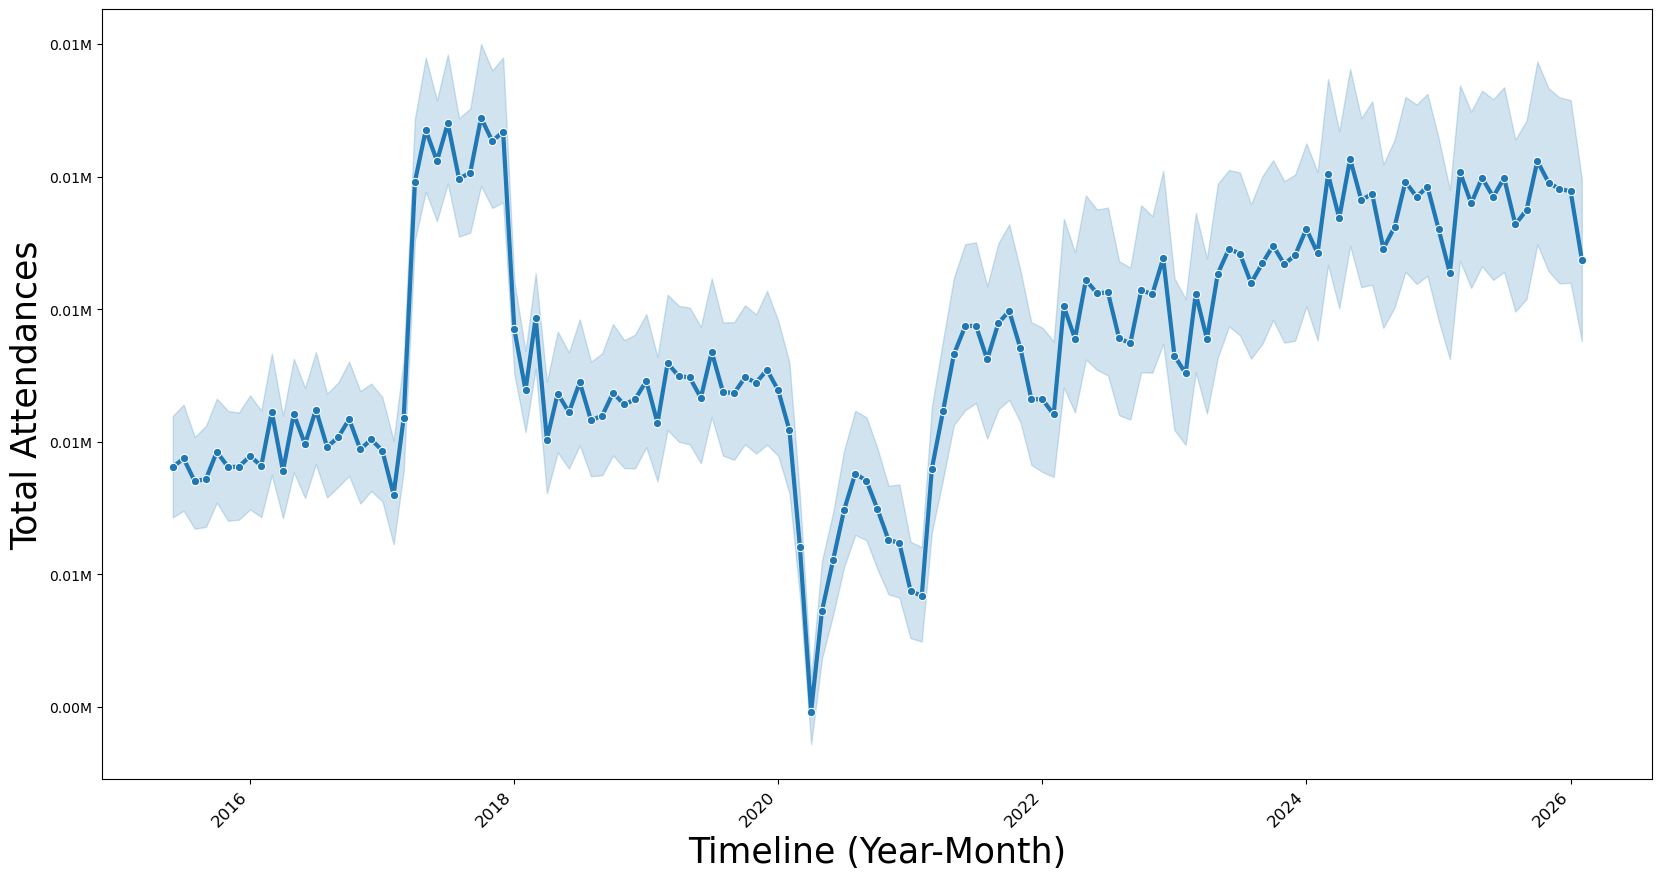

In [15]:
plt.figure(figsize=(20,10),dpi=100)

ax = sns.lineplot(data=finalData, x="MonthYear", y="Total Attendances", marker="o", linewidth=3)
plt.ylabel("Total Attendances",fontsize=25)
plt.xlabel("Timeline (Year-Month)",fontsize=25)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))
plt.xticks(rotation=45, ha='right', fontsize=12);
plt.savefig("halfTrend")

In [16]:
finalData = finalData[finalData["MonthYear"] >= "2022-01-01"]

In [17]:
attendanceTrend = finalData.groupby('MonthYear', as_index=False)['Total Attendances'].sum()

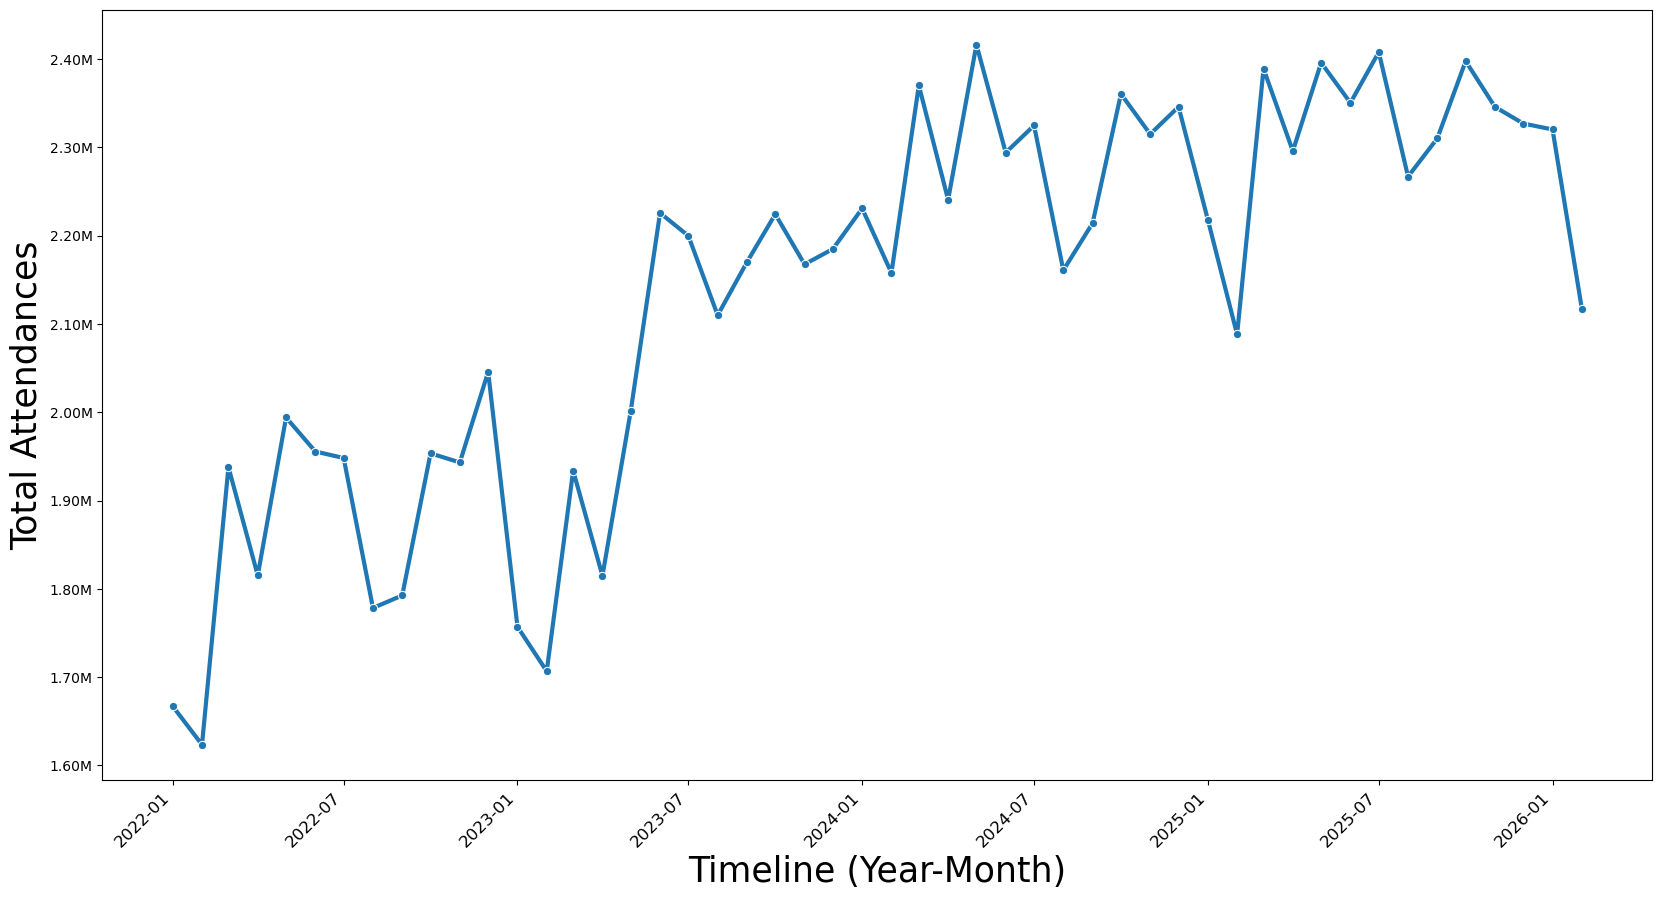

In [18]:
plt.figure(figsize=(20,10),dpi=100)

ax = sns.lineplot(data=attendanceTrend, x="MonthYear", y="Total Attendances", marker="o", linewidth=3)
plt.ylabel("Total Attendances",fontsize=25)
plt.xlabel("Timeline (Year-Month)",fontsize=25)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))
plt.xticks(rotation=45, ha='right', fontsize=12);
plt.savefig("halfTrend")
